In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# load the data, all selected 54 features and Imax

# load the features
features_df = pd.read_csv('data/features_df_v1.csv')
mX = features_df.loc[:, "f1_mass_PC1":].astype(float).values # bring all standardized features to the float
print(f'The shape of the feature matrix is {mX.shape}')

# load the data
data_df = pd.read_csv('data/waka_dragon_merged.csv')
vY = data_df['Imax'].astype(float).values
print(f'The shape of the target vector is {vY.shape}')

The shape of the feature matrix is (312, 54)
The shape of the target vector is (312,)


In [4]:
# ML imports
from sklearn.linear_model import LinearRegression, lasso_path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline


In [5]:
# as a first step i want to implement a linear regression model strightforward on all set
oLinReg = LinearRegression().fit(mX, vY) # creating og linear regression model
vY_pred = oLinReg.predict(mX) # predicting Imax

# calculate the R2 score
r2 = r2_score(vY, vY_pred)
mae = mean_absolute_error(vY, vY_pred) # This score value is most important for me
print(f'The R2 score is {r2:.2f}')
print(f'The MAE is {mae:.2f}')


The R2 score is 0.63
The MAE is 7.32


In [6]:
# as next step i want to do cross-validation
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42) # split for all samples
vY_pred = cross_val_predict(oLinReg, mX, vY, cv=kf)

# calculate the R2 score
r2 = r2_score(vY, vY_pred)
print(f'The R2 score is {r2:.2f}')
# calculate the MAE
mae = mean_absolute_error(vY, vY_pred)
print(f'The MAE is {mae:.2f}')

The R2 score is 0.22
The MAE is 9.45


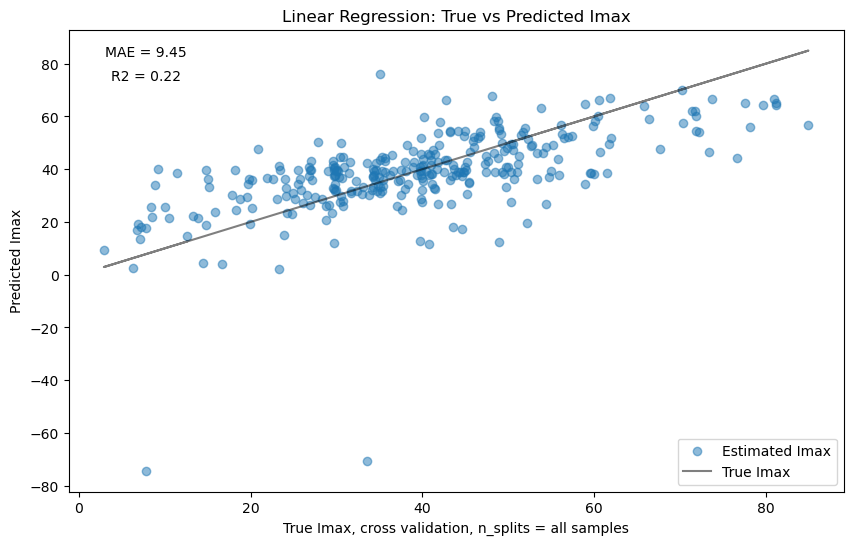

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(vY, vY_pred, alpha=0.5, label='Estimated Imax')
plt.plot(vY, vY, label='True Imax', color='black', alpha=0.5)
ax.set_xlabel('True Imax, cross validation, n_splits = all samples')
ax.set_ylabel('Predicted Imax')
ax.set_title('Linear Regression: True vs Predicted Imax')
ax.text(0.1, 0.95, f'MAE = {mae:.2f}', transform=ax.transAxes, ha='center', va='center')
ax.text(0.1, 0.9, f'R2 = {r2:.2f}', transform=ax.transAxes, ha='center', va='center')
ax.legend()
plt.show()


The are tree not well-understood outlayer prediction

In [8]:
# as next step i want to try Lasso regression

# define the range of alpha values
lAlpha = np.linspace(0.0001, 5, 100) # range of alpha values after preliminary tunning
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42) # split for all samples
# i want to create an empty dataframe with the columns alpha, R2, MAE, RMSE, MSE
dfLasso = pd.DataFrame(columns=['alpha', 'R2', 'MAE', 'RMSE', 'MSE'], dtype=float)
dfLasso['alpha'] = lAlpha
dfLasso['R2'] = [0.0] * len(lAlpha)
dfLasso['MAE'] = [0.0] * len(lAlpha)
dfLasso['RMSE'] = [0.0] * len(lAlpha)
dfLasso['MSE'] = [0.0] * len(lAlpha)

for i, alpha in enumerate(lAlpha):
    print(f"Training Lasso with alpha = {alpha} model {i+1} of {len(lAlpha)}")
    oLasso = Lasso(alpha=alpha, max_iter=10_000)
    vY_pred = cross_val_predict(oLasso, mX, vY, cv=kf)
    dfLasso.loc[i, 'R2'] = r2_score(vY, vY_pred)
    dfLasso.loc[i, 'MAE'] = mean_absolute_error(vY, vY_pred)
    dfLasso.loc[i, 'RMSE'] = np.sqrt(mean_squared_error(vY, vY_pred))
    dfLasso.loc[i, 'MSE'] = mean_squared_error(vY, vY_pred)



Training Lasso with alpha = 0.0001 model 1 of 100


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.363e+04, tolerance: 7.587e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.366e+04, tolerance: 7.532e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

Training Lasso with alpha = 0.05060404040404041 model 2 of 100
Training Lasso with alpha = 0.10110808080808081 model 3 of 100
Training Lasso with alpha = 0.1516121212121212 model 4 of 100
Training Lasso with alpha = 0.2021161616161616 model 5 of 100
Training Lasso with alpha = 0.252620202020202 model 6 of 100
Training Lasso with alpha = 0.3031242424242424 model 7 of 100
Training Lasso with alpha = 0.35362828282828285 model 8 of 100
Training Lasso with alpha = 0.40413232323232323 model 9 of 100
Training Lasso with alpha = 0.4546363636363636 model 10 of 100
Training Lasso with alpha = 0.5051404040404041 model 11 of 100
Training Lasso with alpha = 0.5556444444444445 model 12 of 100
Training Lasso with alpha = 0.6061484848484848 model 13 of 100
Training Lasso with alpha = 0.6566525252525253 model 14 of 100
Training Lasso with alpha = 0.7071565656565657 model 15 of 100
Training Lasso with alpha = 0.757660606060606 model 16 of 100
Training Lasso with alpha = 0.8081646464646465 model 17 of 10

In [9]:
dfLasso.head()

,alpha,R2,MAE,RMSE,MSE
0,0.000100,0.228439,9.429112,13.709981,187.963577
1,0.050604,0.372391,8.971195,12.365058,152.894668
2,0.101108,0.384094,9.039129,12.249238,150.043827
3,0.151612,0.389251,9.064541,12.197850,148.787535
4,0.202116,0.395029,9.092577,12.140006,147.379751


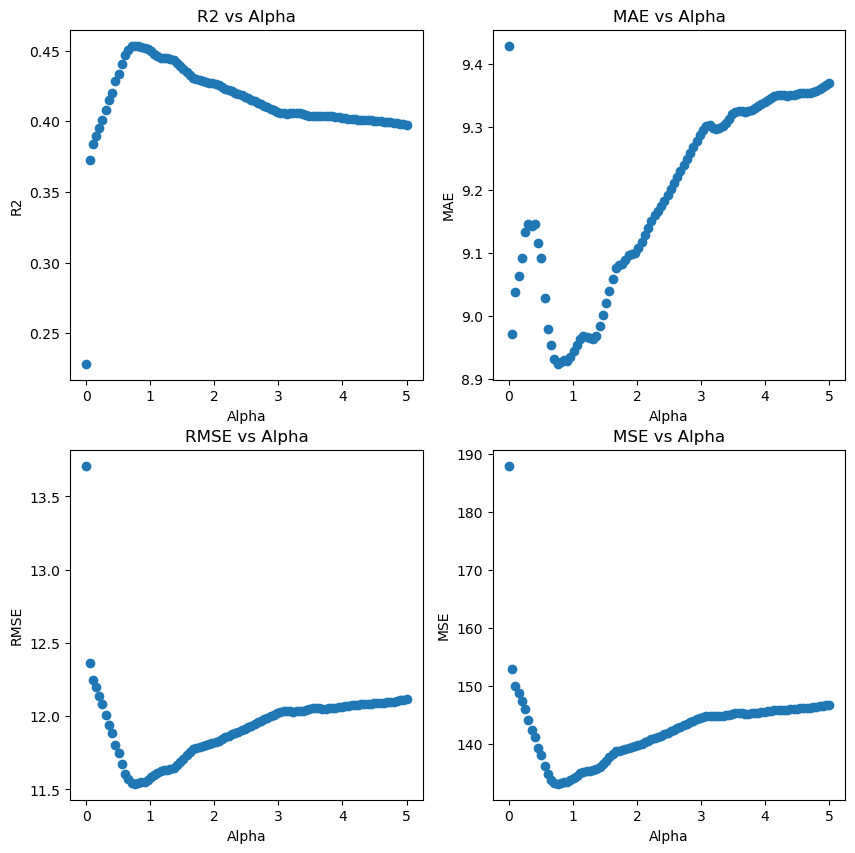

In [10]:
# want to plot 4 subplots for R2, MAE, RMSE, MSE vs alpha
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
ax[0, 0].scatter(dfLasso['alpha'], dfLasso['R2'])           
ax[0, 0].set_xlabel('Alpha')
ax[0, 0].set_ylabel('R2')
ax[0, 0].set_title('R2 vs Alpha')

ax[0, 1].scatter(dfLasso['alpha'], dfLasso['MAE'])
ax[0, 1].set_xlabel('Alpha')
ax[0, 1].set_ylabel('MAE')
ax[0, 1].set_title('MAE vs Alpha')

ax[1, 0].scatter(dfLasso['alpha'], dfLasso['RMSE'])
ax[1, 0].set_xlabel('Alpha')
ax[1, 0].set_ylabel('RMSE')
ax[1, 0].set_title('RMSE vs Alpha')

ax[1, 1].scatter(dfLasso['alpha'], dfLasso['MSE'])
ax[1, 1].set_xlabel('Alpha')
ax[1, 1].set_ylabel('MSE')
ax[1, 1].set_title('MSE vs Alpha')

plt.show()


In [17]:
# now let's choose the model with the smallest MAE
optimal_alpha_Lasso = dfLasso.loc[dfLasso['MAE'].idxmin(), 'alpha']
print(f'The optimal alpha is {optimal_alpha_Lasso:.4f}')

The optimal alpha is 0.7577


In [11]:
# let's investigate with lasso_path the importance of the features
from sklearn.linear_model import lasso_path
alphasPath, coefsPath, *_ = lasso_path(features_df.loc[:, "f1_mass_PC1":],  data_df['Imax'], alphas= lAlpha)


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.265e+01, tolerance: 5.600e+01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.557e+05, tolerance: 5.600e+01
  model = cd_fast.enet_coordinate_descent_gram(


In [12]:
alphasPath.shape

(100,)

In [13]:
coefsPath.shape

(54, 100)

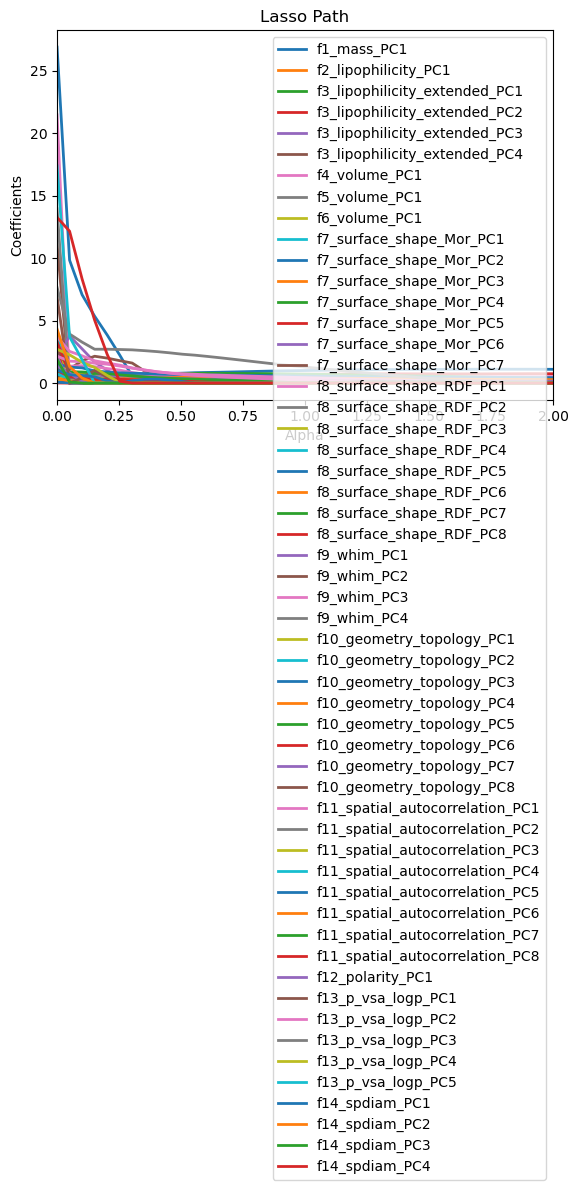

In [14]:
plt.plot(alphasPath, np.abs(coefsPath.T), lw = 2, label = features_df.loc[:, "f1_mass_PC1":].columns.to_list())
plt.xlim(0, 2)
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso Path')
plt.legend(loc = 'upper right')
plt.show()


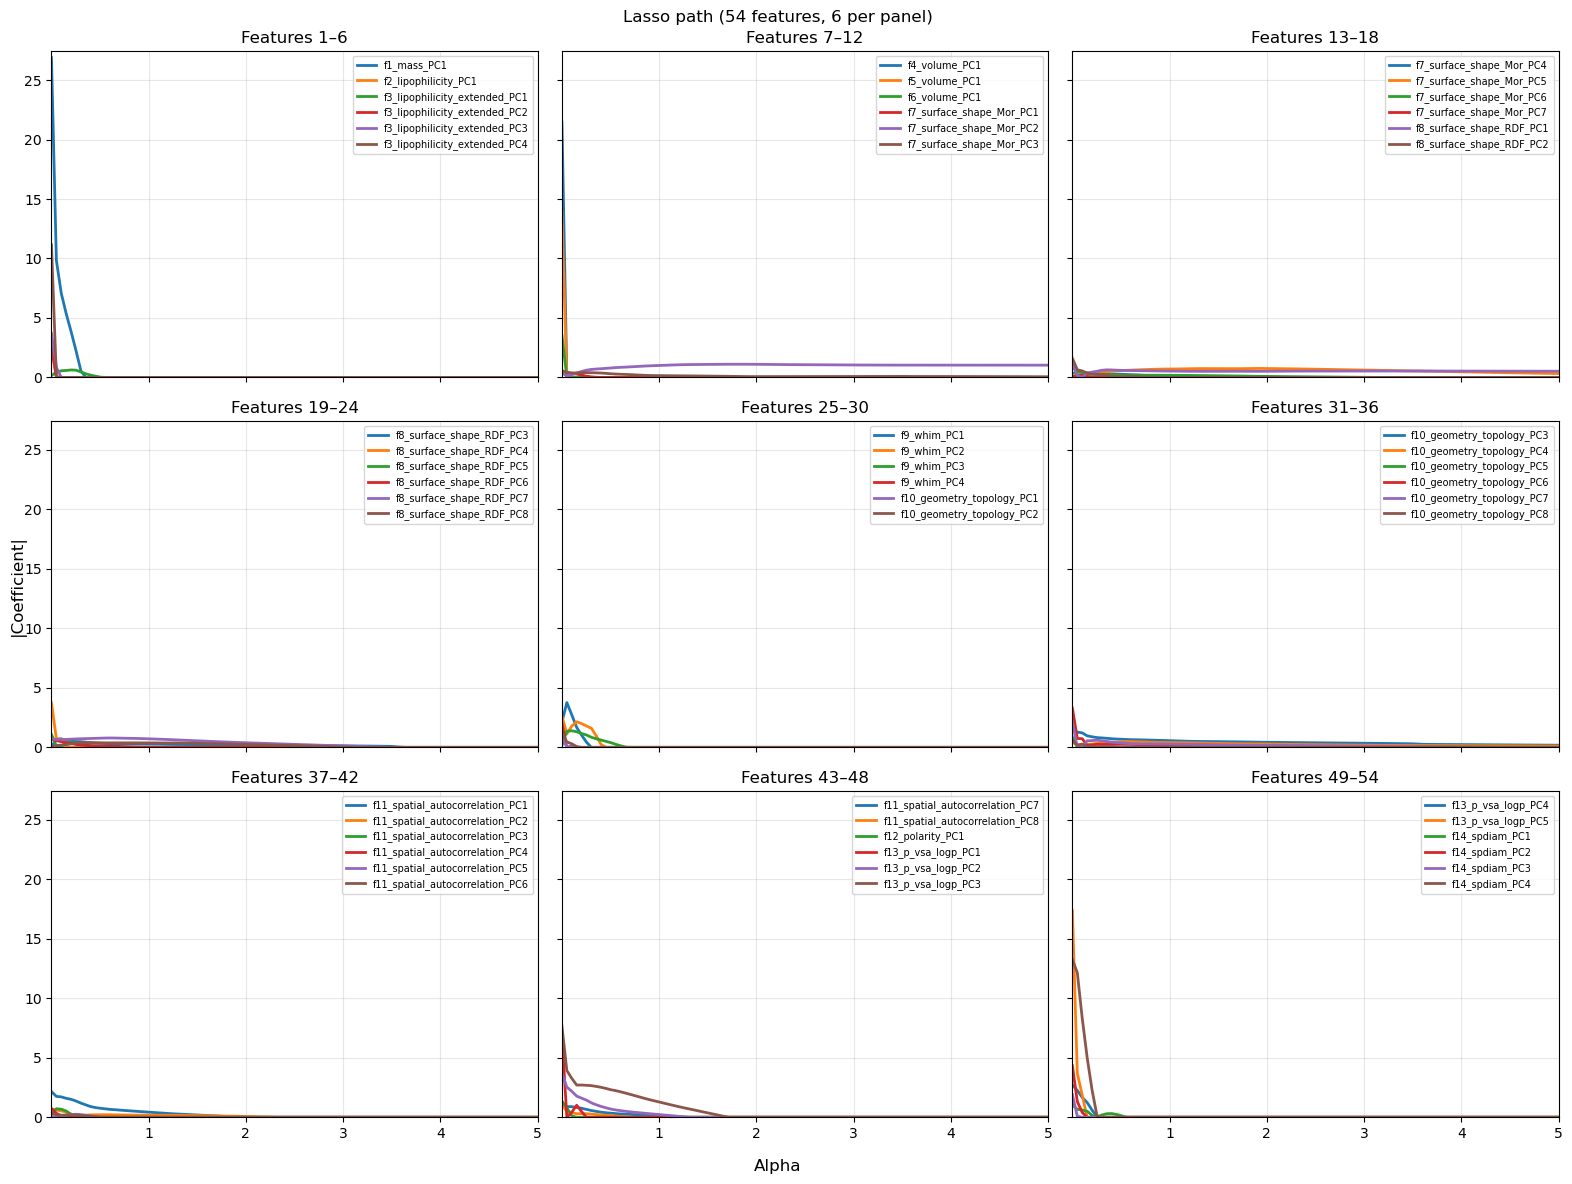

In [15]:
feature_names = features_df.loc[:, "f1_mass_PC1":].columns.to_list()
abs_coefs = np.abs(coefsPath)  # (54, n_alphas)

# Global limits so every subplot uses the same frame
xlim = (alphasPath.min(), alphasPath.max())
ylim = (0, abs_coefs.max() * 1.02)  # small top margin

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for k, ax in enumerate(axes.flat):
    i0, i1 = k * 6, k * 6 + 6
    for i in range(i0, i1):
        ax.plot(alphasPath, abs_coefs[i], lw=2, label=feature_names[i])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'Features {i0 + 1}–{i1}')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)

fig.supxlabel('Alpha')
fig.supylabel('|Coefficient|')
fig.suptitle('Lasso path (54 features, 6 per panel)')
plt.tight_layout()
plt.show()

In [19]:
# CV-optimal Lasso alpha (rename earlier cell or define here)
optimal_alpha_Lasso = dfLasso.loc[dfLasso['MAE'].idxmin(), 'alpha']
print(f'Optimal Lasso alpha: {optimal_alpha_Lasso:.4f}')

feature_names = features_df.loc[:, "f1_mass_PC1":].columns

# Fit once at optimal alpha — do not reuse oLasso from the CV loop
oLasso_opt = Lasso(alpha=optimal_alpha_Lasso, max_iter=500_000)
oLasso_opt.fit(mX, vY)

coef_lasso = pd.Series(oLasso_opt.coef_, index=feature_names)
top10_lasso = coef_lasso.abs().sort_values(ascending=False).head(10)
top10_lasso_signed = coef_lasso.reindex(top10_lasso.index)

print('Top 10 by |coefficient|:')
print(top10_lasso)
print('\nWith sign (standardized features):')
print(top10_lasso_signed)

# Optional: tidy table
pd.DataFrame({
    'abs_coef': top10_lasso,
    'coef': top10_lasso_signed,
    'rank': range(1, 11),
}).set_index(top10_lasso.index)

Optimal Lasso alpha: 0.7577
Top 10 by |coefficient|:
f13_p_vsa_logp_PC3                 1.801187
f7_surface_shape_Mor_PC2           0.913215
f8_surface_shape_RDF_PC7           0.766778
f7_surface_shape_Mor_PC5           0.662235
f10_geometry_topology_PC3          0.618447
f11_spatial_autocorrelation_PC1    0.569843
f8_surface_shape_RDF_PC1           0.559022
f10_geometry_topology_PC4          0.446792
f13_p_vsa_logp_PC2                 0.411271
f8_surface_shape_RDF_PC8           0.375993
dtype: float64

With sign (standardized features):
f13_p_vsa_logp_PC3                -1.801187
f7_surface_shape_Mor_PC2          -0.913215
f8_surface_shape_RDF_PC7           0.766778
f7_surface_shape_Mor_PC5           0.662235
f10_geometry_topology_PC3         -0.618447
f11_spatial_autocorrelation_PC1    0.569843
f8_surface_shape_RDF_PC1          -0.559022
f10_geometry_topology_PC4         -0.446792
f13_p_vsa_logp_PC2                 0.411271
f8_surface_shape_RDF_PC8          -0.375993
dtype: float64


,abs_coef,coef,rank
f13_p_vsa_logp_PC3,1.801187,-1.801187,1
f7_surface_shape_Mor_PC2,0.913215,-0.913215,2
f8_surface_shape_RDF_PC7,0.766778,0.766778,3
f7_surface_shape_Mor_PC5,0.662235,0.662235,4
f10_geometry_topology_PC3,0.618447,-0.618447,5
f11_spatial_autocorrelation_PC1,0.569843,0.569843,6
f8_surface_shape_RDF_PC1,0.559022,-0.559022,7
f10_geometry_topology_PC4,0.446792,-0.446792,8
f13_p_vsa_logp_PC2,0.411271,0.411271,9
f8_surface_shape_RDF_PC8,0.375993,-0.375993,10


In [23]:
# now let's train the model with the optimal alpha on whole dataset
oLasso = Lasso(alpha=optimal_alpha_Lasso, max_iter=500_000)
oLasso.fit(mX, vY)
vY_pred_lasso = oLasso.predict(mX)

# calculate the R2 score
r2_lasso = r2_score(vY, vY_pred)
print(f'The R2 score is {r2_lasso:.2f}')
# calculate the MAE
mae_lasso = mean_absolute_error(vY, vY_pred)
print(f'The MAE is {mae_lasso:.2f}')
# calculate the RMSE
rmse_lasso = np.sqrt(mean_squared_error(vY, vY_pred))
print(f'The RMSE is {rmse_lasso:.2f}')
# calculate the MSE
mse_lasso = mean_squared_error(vY, vY_pred)
print(f'The MSE is {mse_lasso:.2f}')


The R2 score is 0.53
The MAE is 8.27
The RMSE is 10.69
The MSE is 114.33


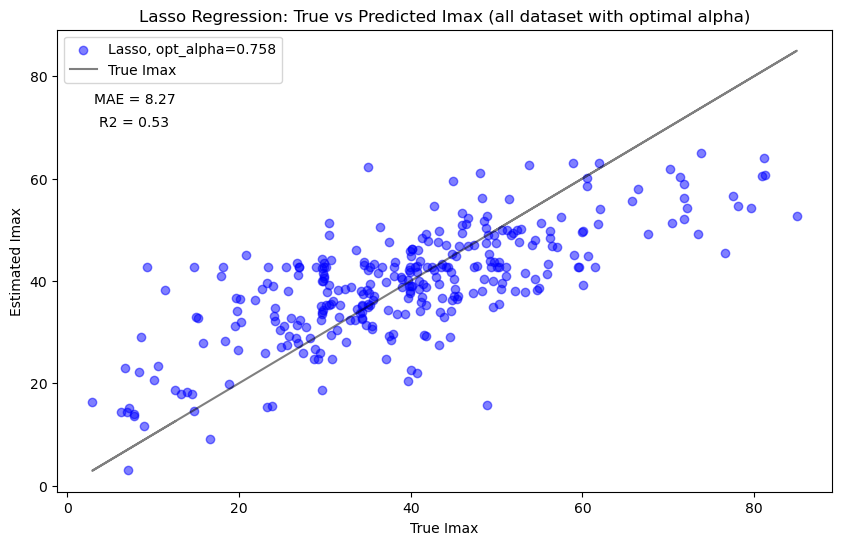

In [29]:
# now let's plot the predicted vs true values
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(vY, vY_pred_lasso, label=f'Lasso, opt_alpha={optimal_alpha_Lasso:.3f}', color='blue',alpha=0.5)
ax.plot(vY, vY, label='True Imax', color='black',alpha=0.5)
ax.set_xlabel('True Imax')
ax.set_ylabel('Estimated Imax')
ax.set_title('Lasso Regression: True vs Predicted Imax (all dataset with optimal alpha)')
ax.text(0.1, 0.85, f'MAE = {mae_lasso:.2f}', transform=ax.transAxes, ha='center', va='center')
ax.text(0.1, 0.8, f'R2 = {r2_lasso:.2f}', transform=ax.transAxes, ha='center', va='center')

plt.legend()
plt.show()

In [30]:
# now i want to do the same with Ridge regression

lAlpha = np.linspace(0.001, 8, 301)
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42) # split for all samples


dfRidge = pd.DataFrame(columns=['alpha', 'R2', 'MAE', 'RMSE', 'MSE'], dtype=float)
dfRidge['alpha'] = lAlpha
dfRidge['R2'] = [0.0] * len(lAlpha)
dfRidge['MAE'] = [0.0] * len(lAlpha)
dfRidge['RMSE'] = [0.0] * len(lAlpha)
dfRidge['MSE'] = [0.0] * len(lAlpha)

for i, alpha in enumerate(lAlpha):
    print(f"Training Ridge with alpha = {alpha} model {i+1} of {len(lAlpha)}")
    oRidge = Ridge(alpha=alpha, max_iter=500_000)
    vY_pred = cross_val_predict(oRidge, mX, vY, cv=kf)
    dfRidge.loc[i, 'R2'] = r2_score(vY, vY_pred)
    dfRidge.loc[i, 'MAE'] = mean_absolute_error(vY, vY_pred)
    dfRidge.loc[i, 'RMSE'] = np.sqrt(mean_squared_error(vY, vY_pred))
    dfRidge.loc[i, 'MSE'] = mean_squared_error(vY, vY_pred)


Training Ridge with alpha = 0.001 model 1 of 301
Training Ridge with alpha = 0.02766333333333333 model 2 of 301
Training Ridge with alpha = 0.05432666666666666 model 3 of 301
Training Ridge with alpha = 0.08098999999999999 model 4 of 301
Training Ridge with alpha = 0.10765333333333332 model 5 of 301
Training Ridge with alpha = 0.13431666666666664 model 6 of 301
Training Ridge with alpha = 0.16097999999999998 model 7 of 301
Training Ridge with alpha = 0.18764333333333333 model 8 of 301
Training Ridge with alpha = 0.21430666666666665 model 9 of 301
Training Ridge with alpha = 0.24096999999999996 model 10 of 301
Training Ridge with alpha = 0.2676333333333333 model 11 of 301
Training Ridge with alpha = 0.29429666666666665 model 12 of 301
Training Ridge with alpha = 0.32095999999999997 model 13 of 301
Training Ridge with alpha = 0.3476233333333333 model 14 of 301
Training Ridge with alpha = 0.37428666666666666 model 15 of 301
Training Ridge with alpha = 0.40095 model 16 of 301
Training Ridg

In [31]:
dfRidge.head()

,alpha,R2,MAE,RMSE,MSE
0,0.001000,0.223962,9.448696,13.749701,189.054278
1,0.027663,0.268265,9.345083,13.351456,178.261372
2,0.054327,0.287024,9.283500,13.179208,173.691526
3,0.080990,0.297873,9.244285,13.078546,171.048362
4,0.107653,0.305194,9.214281,13.010186,169.264946


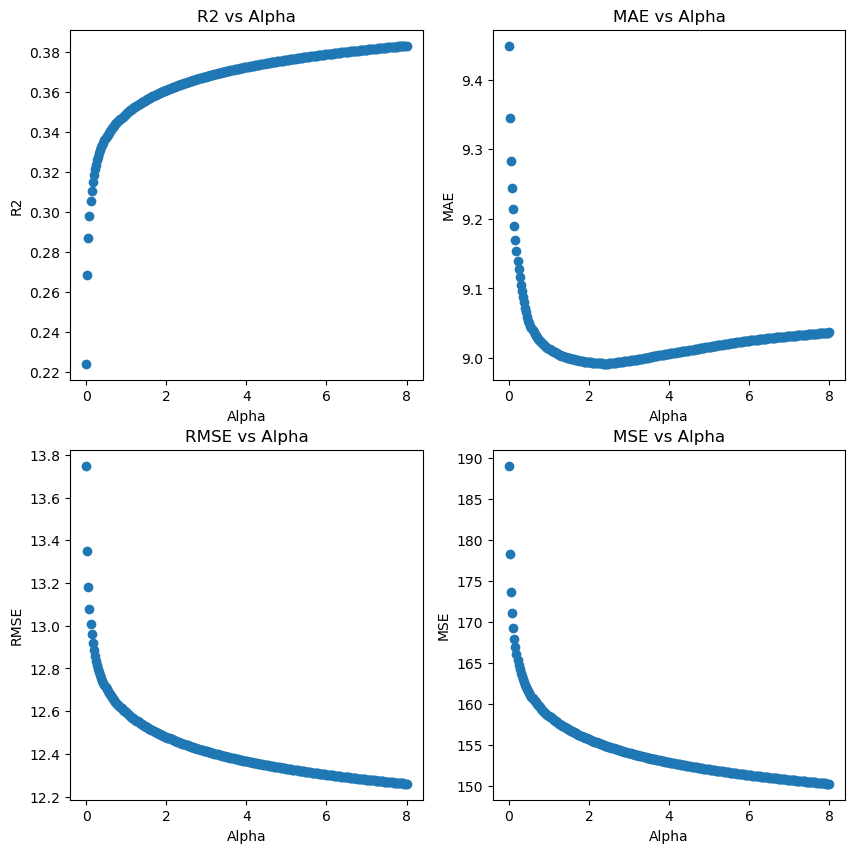

In [32]:
# visualization of the Ridge regression
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
ax[0, 0].scatter(dfRidge['alpha'], dfRidge['R2'])
ax[0, 0].set_xlabel('Alpha')
ax[0, 0].set_ylabel('R2')
ax[0, 0].set_title('R2 vs Alpha')

ax[0, 1].scatter(dfRidge['alpha'], dfRidge['MAE'])
ax[0, 1].set_xlabel('Alpha')
ax[0, 1].set_ylabel('MAE')
ax[0, 1].set_title('MAE vs Alpha')

ax[1, 0].scatter(dfRidge['alpha'], dfRidge['RMSE'])
ax[1, 0].set_xlabel('Alpha')
ax[1, 0].set_ylabel('RMSE')
ax[1, 0].set_title('RMSE vs Alpha') 

ax[1, 1].scatter(dfRidge['alpha'], dfRidge['MSE'])
ax[1, 1].set_xlabel('Alpha')
ax[1, 1].set_ylabel('MSE')
ax[1, 1].set_title('MSE vs Alpha')

plt.show()






In [33]:
# finding the best alpha for Ridge regression
optimal_alpha_ridge = dfRidge.loc[dfRidge['MAE'].idxmin(), 'alpha']
print(f'The optimal alpha is {optimal_alpha_ridge:.4f}')
# now let's train the model with the optimal alpha on whole dataset
oRidge = Ridge(alpha=optimal_alpha_ridge, max_iter=500_000)
oRidge.fit(mX, vY)
vY_pred_ridge = oRidge.predict(mX)

# calculate the R2 score
r2_ridge = r2_score(vY, vY_pred_ridge)
print(f'The R2 score is {r2_ridge:.2f}')
# calculate the MAE
mae_ridge = mean_absolute_error(vY, vY_pred_ridge)
print(f'The MAE is {mae_ridge:.2f}')
# calculate the RMSE
rmse_ridge = np.sqrt(mean_squared_error(vY, vY_pred_ridge))
print(f'The RMSE is {rmse_ridge:.2f}')

# calculate the MSE
mse_ridge = mean_squared_error(vY, vY_pred_ridge)
print(f'The MSE is {mse_ridge:.2f}')

The optimal alpha is 2.4540
The R2 score is 0.61
The MAE is 7.44
The RMSE is 9.69
The MSE is 93.88


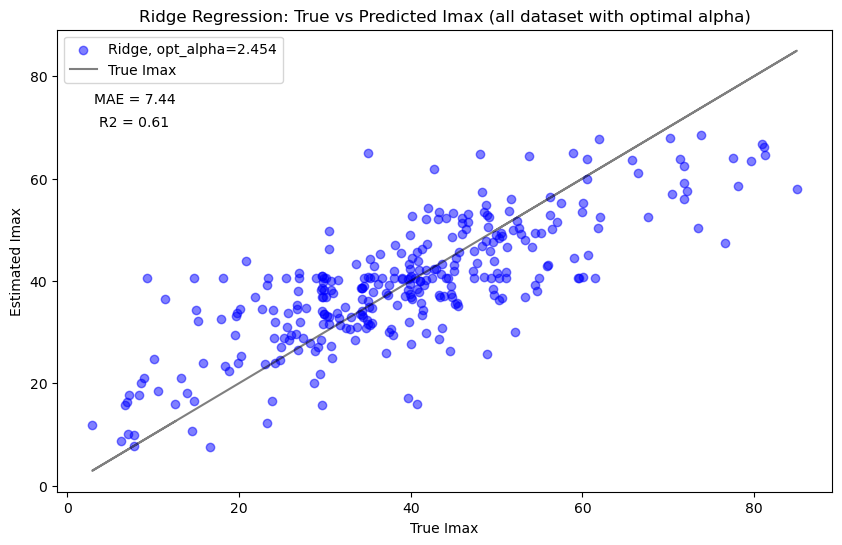

In [35]:
# Now i want to plot the predicted vs true values for Ridge regression
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(vY, vY_pred_ridge, label=f'Ridge, opt_alpha={optimal_alpha_ridge:.3f}', color='blue',alpha=0.5)
ax.plot(vY, vY, label='True Imax', color='black',alpha=0.5)
ax.set_xlabel('True Imax')
ax.set_ylabel('Estimated Imax')
ax.set_title('Ridge Regression: True vs Predicted Imax (all dataset with optimal alpha)')
ax.text(0.1, 0.85, f'MAE = {mae_ridge:.2f}', transform=ax.transAxes, ha='center', va='center')
ax.text(0.1, 0.8, f'R2 = {r2_ridge:.2f}', transform=ax.transAxes, ha='center', va='center')
plt.legend()
plt.show()

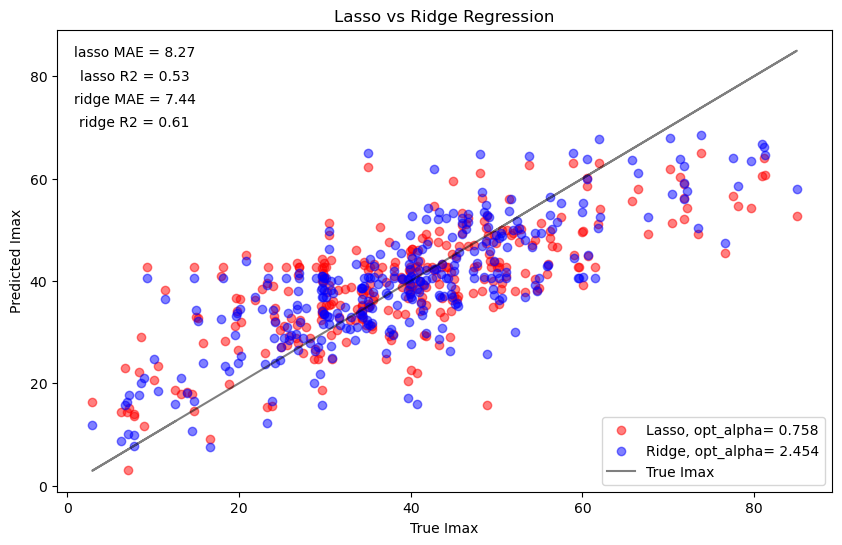

In [40]:
# now i want to plot scatter plots one for optimal alpha for lasso and one for optimal alpha for ridge


fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(vY, vY_pred_lasso, label=f'Lasso, opt_alpha= {optimal_alpha_Lasso:.3f}', color='red',alpha=0.5)
plt.scatter(vY, vY_pred_ridge, label=f'Ridge, opt_alpha= {optimal_alpha_ridge:.3f}', color='blue',alpha=0.5)
plt.plot(vY, vY, label='True Imax', color='black',alpha=0.5)
plt.xlabel('True Imax')
plt.ylabel('Predicted Imax')
plt.title('Lasso vs Ridge Regression')
ax.text(0.1, 0.95, f'lasso MAE = {mae_lasso:.2f}', transform=ax.transAxes, ha='center', va='center')
ax.text(0.1, 0.9, f'lasso R2 = {r2_lasso:.2f}', transform=ax.transAxes, ha='center', va='center')
ax.text(0.1, 0.85, f'ridge MAE = {mae_ridge:.2f}', transform=ax.transAxes, ha='center', va='center')
ax.text(0.1, 0.8, f'ridge R2 = {r2_ridge:.2f}', transform=ax.transAxes, ha='center', va='center')
plt.legend()
plt.show()


In [41]:
# same as for lasso i want to precent the top 10 features for ridge
# CV-optimal Lasso alpha (rename earlier cell or define here)
optimal_alpha_Ridge = dfRidge.loc[dfRidge['MAE'].idxmin(), 'alpha']
print(f'Optimal Ridge alpha: {optimal_alpha_Ridge:.4f}')

feature_names = features_df.loc[:, "f1_mass_PC1":].columns

# Fit once at optimal alpha — do not reuse oLasso from the CV loop
oRidge_opt = Ridge(alpha=optimal_alpha_Ridge, max_iter=500_000)
oRidge_opt.fit(mX, vY)

coef_ridge   = pd.Series(oRidge_opt.coef_, index=feature_names)
top10_ridge = coef_ridge.abs().sort_values(ascending=False).head(10)
top10_ridge_signed = coef_ridge.reindex(top10_ridge.index)

print('Top 10 by |coefficient|:')
print(top10_ridge)
print('\nWith sign (standardized features):')
print(top10_ridge_signed)

# Optional: tidy table
pd.DataFrame({
    'abs_coef': top10_ridge,
    'coef': top10_ridge_signed,
    'rank': range(1, 11),
}).set_index(top10_ridge.index)

Optimal Ridge alpha: 2.4540
Top 10 by |coefficient|:
f14_spdiam_PC4                   11.218676
f1_mass_PC1                       7.858843
f13_p_vsa_logp_PC3                4.237427
f13_p_vsa_logp_PC5                3.929406
f3_lipophilicity_extended_PC4     3.651141
f9_whim_PC1                       3.214441
f8_surface_shape_RDF_PC4          2.853095
f3_lipophilicity_extended_PC3     2.731077
f14_spdiam_PC2                    2.672176
f13_p_vsa_logp_PC2                2.502486
dtype: float64

With sign (standardized features):
f14_spdiam_PC4                   11.218676
f1_mass_PC1                      -7.858843
f13_p_vsa_logp_PC3               -4.237427
f13_p_vsa_logp_PC5               -3.929406
f3_lipophilicity_extended_PC4    -3.651141
f9_whim_PC1                       3.214441
f8_surface_shape_RDF_PC4          2.853095
f3_lipophilicity_extended_PC3     2.731077
f14_spdiam_PC2                    2.672176
f13_p_vsa_logp_PC2                2.502486
dtype: float64


,abs_coef,coef,rank
f14_spdiam_PC4,11.218676,11.218676,1
f1_mass_PC1,7.858843,-7.858843,2
f13_p_vsa_logp_PC3,4.237427,-4.237427,3
f13_p_vsa_logp_PC5,3.929406,-3.929406,4
f3_lipophilicity_extended_PC4,3.651141,-3.651141,5
f9_whim_PC1,3.214441,3.214441,6
f8_surface_shape_RDF_PC4,2.853095,2.853095,7
f3_lipophilicity_extended_PC3,2.731077,2.731077,8
f14_spdiam_PC2,2.672176,2.672176,9
f13_p_vsa_logp_PC2,2.502486,2.502486,10


In [43]:
from sklearn.linear_model import RANSACRegressor

In [61]:
# now i want to perform robust regression with ransac on ridge estimator
print(f"Optimal alpha for Ridge regression is {optimal_alpha_ridge:.4f}")

minNumSamples = np.linspace(0.1, 0.9, 50)
ransac_results_df = pd.DataFrame(columns=['min_samples', 'R2', 'MAE', 'RMSE', 'MSE'])
ransac_results_df['min_samples'] = minNumSamples
ransac_results_df['R2'] = [0.0] * len(minNumSamples)
ransac_results_df['MAE'] = [0.0] * len(minNumSamples)
ransac_results_df['RMSE'] = [0.0] * len(minNumSamples)
ransac_results_df['MSE'] = [0.0] * len(minNumSamples)

for i, min_samples in enumerate(minNumSamples):
    oRidge = Ridge(alpha=optimal_alpha_ridge, max_iter=500_000)
    oRansac = RANSACRegressor(estimator=oRidge, min_samples=min_samples, max_trials=10_000).fit(mX, vY)
    vY_pred_ransac = oRansac.predict(mX)
    ransac_results_df.loc[i, 'R2'] = r2_score(vY, vY_pred_ransac)
    ransac_results_df.loc[i, 'MAE'] = mean_absolute_error(vY, vY_pred_ransac)
    ransac_results_df.loc[i, 'RMSE'] = np.sqrt(mean_squared_error(vY, vY_pred_ransac))
    ransac_results_df.loc[i, 'MSE'] = mean_squared_error(vY, vY_pred_ransac)

ransac_results_df.head()


Optimal alpha for Ridge regression is 2.4540


,min_samples,R2,MAE,RMSE,MSE
0,0.100000,0.424969,8.477149,11.835792,140.085979
1,0.116327,0.300558,8.778945,13.053517,170.394318
2,0.132653,0.295560,8.960046,13.100073,171.611901
3,0.148980,-0.042670,9.277828,15.937686,254.009823
4,0.165306,0.423777,8.433884,11.848050,140.376299


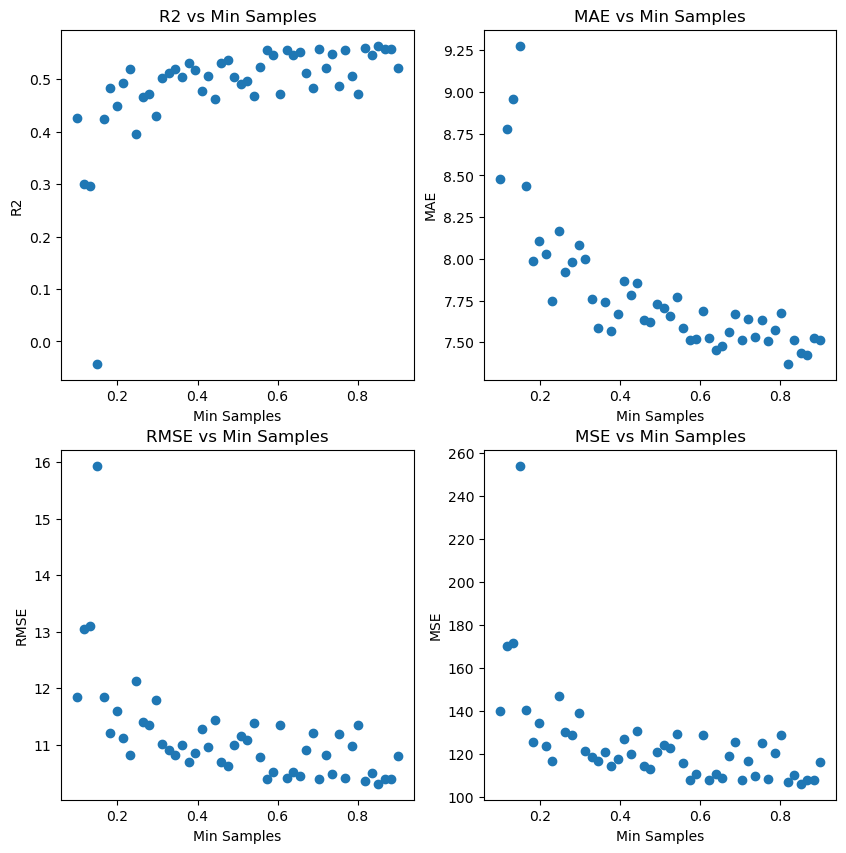

In [62]:
# want to plot 4 supplots and check the R2 and MAE RMSE and MSE for different min_samples
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
ax[0, 0].scatter(ransac_results_df['min_samples'], ransac_results_df['R2'])
ax[0, 0].set_xlabel('Min Samples')
ax[0, 0].set_ylabel('R2')
ax[0, 0].set_title('R2 vs Min Samples')

ax[0, 1].scatter(ransac_results_df['min_samples'], ransac_results_df['MAE'])
ax[0, 1].set_xlabel('Min Samples')
ax[0, 1].set_ylabel('MAE')
ax[0, 1].set_title('MAE vs Min Samples')    

ax[1, 0].scatter(ransac_results_df['min_samples'], ransac_results_df['RMSE'])
ax[1, 0].set_xlabel('Min Samples')
ax[1, 0].set_ylabel('RMSE')
ax[1, 0].set_title('RMSE vs Min Samples')   

ax[1, 1].scatter(ransac_results_df['min_samples'], ransac_results_df['MSE'])
ax[1, 1].set_xlabel('Min Samples')
ax[1, 1].set_ylabel('MSE')
ax[1, 1].set_title('MSE vs Min Samples')

plt.show()







In [63]:
optimal_min_samples = ransac_results_df.loc[ransac_results_df['MAE'].idxmin(), 'min_samples']
optimal_min_samples

np.float64(0.8183673469387756)

In [64]:
ransac_results_df.loc[ransac_results_df['min_samples'] == optimal_min_samples]

,min_samples,R2,MAE,RMSE,MSE
44,0.818367,0.55948,7.370553,10.359395,107.317074


In [48]:
ridge_ransac_r2 = ransac_results_df.loc[ransac_results_df['min_samples'] == optimal_min_samples, 'R2'].values[0]
ridge_ransac_mae = ransac_results_df.loc[ransac_results_df['min_samples'] == optimal_min_samples, 'MAE'].values[0]

In [49]:
ridge_ransac_mae

np.float64(7.382407796811569)

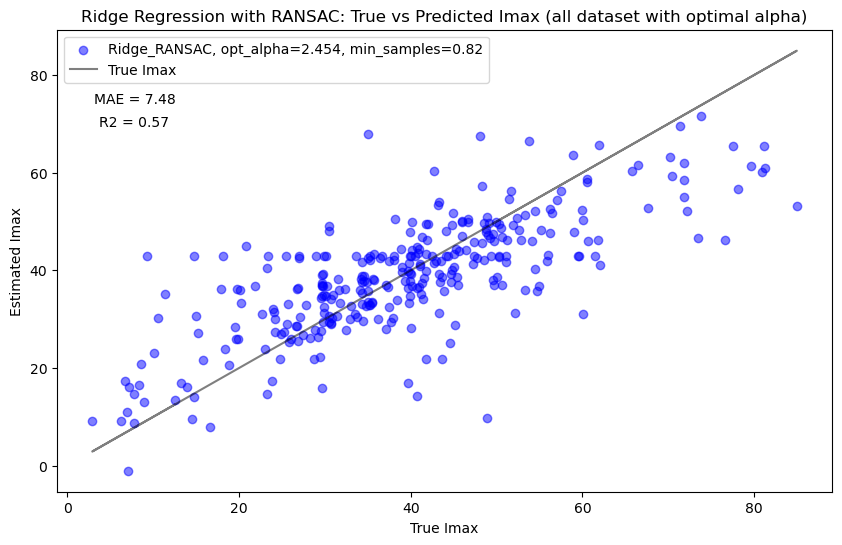

In [68]:
oRidge = Ridge(alpha=optimal_alpha_ridge, max_iter=500_000)
oRansac = RANSACRegressor(estimator=oRidge, min_samples=optimal_min_samples, max_trials=100).fit(mX, vY)
vY_pred_ransac = oRansac.predict(mX)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(vY, vY_pred_ransac, label=f'Ridge_RANSAC, opt_alpha={optimal_alpha_ridge:.3f}, min_samples={optimal_min_samples:.2f}', color='blue',alpha=0.5)
ax.plot(vY, vY, label='True Imax', color='black',alpha=0.5)
ax.set_xlabel('True Imax')
ax.set_ylabel('Estimated Imax')
ax.set_title('Ridge Regression with RANSAC: True vs Predicted Imax (all dataset with optimal alpha)')
ridge_ransac_mae = mean_absolute_error(vY, vY_pred_ransac)
ridge_ransac_r2 = r2_score(vY, vY_pred_ransac)
ax.text(0.1, 0.85, f'MAE = {ridge_ransac_mae:.2f}', transform=ax.transAxes, ha='center', va='center')
ax.text(0.1, 0.8, f'R2 = {ridge_ransac_r2:.2f}', transform=ax.transAxes, ha='center', va='center')
plt.legend()
plt.show()